# PatchTST OHLCV forecasting -- HF PatchTSTModel replication of steven's task

**Step 2 of the experiment ladder: volume dropped entirely** (not a training target, not a
context input channel). Target parameterization is otherwise unchanged from step 1
(`hf_patchtst_fused_head`) -- still the anchored log-return decomposition
(`open_ret`/`body_ret`/wicks), fused head, `channel_attention` swept.

**Why drop volume**: in step 1's training logs, `price_loss` was ~7e-5 while `vol_loss` was
~0.18-0.27 -- `log_volume_norm` is z-scored to ~unit variance while the price targets are
tiny raw log-returns, so even at `w_vol=0.5`, `weighted_mse_loss`'s combined
`price_loss + 0.5*vol_loss` was overwhelmingly dominated by the volume term. Almost all
gradient signal was "get better at volume," not price -- and volume predictions aren't used
downstream anyway (not in the backtest, not in confidence scoring).

**This variant no longer reuses `weighted_mse_loss`/`unpack_y` from `steven/src/losses.py`**
-- those hard-require a volume term. A local `price_only_mse_loss` replaces them (see
"Model" below).

**Known risk, carried over from an earlier run of this exact combination (return target +
volume dropped) on this branch**: that run got much better OHLC MAE/RMSE, but the backtest
produced **zero trades at every confidence threshold** -- MSE found "predict ~0" as a cheap
shortcut for a near-random-walk return target once volume (the one loss term with real
variance to chase) was removed, destroying directional signal even though point-error
looked great. Watch **directional accuracy**, not just OHLC RMSE, when reading this run's
result -- a large RMSE improvement paired with directional accuracy dropping toward/at
chance would be the same failure mode recurring, not a genuine win.

`steven/src/models/patchtst.py` is a hand-rolled PatchTST-style transformer: it patches
the input (7-bar / 1-trading-day patches) and self-attends across patches, but does
**early channel fusion** -- all 7 feature channels are flattened together into one linear
patch embedding before any attention happens. It does not use the paper's channel-independence
design, and has no way to toggle channel-mixing on/off.

This notebook replicates steven's exact **task** (same data, same target parameterization)
with the real HF `PatchTSTModel` backbone instead, which *does* implement
channel-independent patching (each channel patched/embedded separately) with an optional
`channel_attention` sublayer to let channels cross-inform each other.

**Kept identical to steven's setup, for a fair comparison:**
- Data: `steven/data/spy_ohlcv_1h.parquet`, same train/val/test date splits (`steven/src/data_pipeline.py`).
- Target parameterization: anchored log-returns per horizon bar (`open_ret`, `body_ret`,
  `upper_wick`, `lower_wick`), 3 bars ahead (`HORIZON=3`), reused directly
  from `steven/src/data_pipeline.py` (`build_dataset`, `reconstruct_prices`) -- no
  reimplementation. Volume dropped (see above).
- Patch structure: `patch_length=7`, `patch_stride=7` (non-overlapping, one trading day per
  patch), matching steven's `PATCH_LEN=7`.
- Training hyperparameters: `lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x
  20,000 resampled windows/epoch -- from `steven/configs/patchtst.yaml`.

**One deliberate simplification**: steven's model trains on a variable-context curriculum
(2-10 trading days, resampled per window). HF `PatchTSTModel` patchifies a single fixed
`context_length` per model, so this notebook fixes `context_length=MAX_CONTEXT=70` (10 trading
days, steven's longest curriculum option) rather than replicating the curriculum -- most
directly comparable to steven's own "long" context bucket in `steven/outputs/metrics.json`,
not his "overall" (mixed-length) numbers.

**Deferred**: the long-only limit-order backtest (`steven/src/evaluate.py`'s `run_backtest`)
is not implemented here -- per instruction, that comes after we've confirmed which
target/volume variant is picked from the forecasting metrics ladder.


## Colab setup

In [16]:
!nvidia-smi --query-gpu=name,memory.total --format=csv


name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB


In [17]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "patchtst_ohlcv_mse"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    #
    # fetch + checkout {BRANCH} (not just `pull`): REPO_DIR persists across notebook runs
    # within the same Colab VM session, so if an earlier run in this session cloned a
    # DIFFERENT branch (e.g. this VM was previously used for a notebook with an older
    # BRANCH value), a bare `pull` here would just pull more commits onto that stale
    # branch instead of switching -- and the push cell at the bottom would then fail with
    # "src refspec {BRANCH} does not match any", since no local branch by that name would
    # exist to push. Explicitly checking out BRANCH every time this cell runs avoids that.
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} checkout {BRANCH}
    !git -C {REPO_DIR} pull origin {BRANCH}

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}


Already on 'patchtst_ohlcv_mse'
Your branch is up to date with 'origin/patchtst_ohlcv_mse'.
From https://github.com/WoodyChang21/ECE1508_GenAI
 * branch            patchtst_ohlcv_mse -> FETCH_HEAD
Already up to date.
/content/ECE1508_GenAI


In [18]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml


In [19]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

`EXPERIMENT` describes *this run* -- it's what gets echoed into each output JSON's
`"experiment"` block and is the thing to paste into `docs/experiments.md`'s row when logging
the result, so the doc and the actual run config can't drift apart. Update `name`/`description`
each time this notebook is repurposed for a different target/volume/loss variant (per the
experiment ladder: fused-head parity check -> drop volume -> raw-price+volume ->
raw-price-no-volume -> head comparison).


In [20]:
import sys, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import (
    build_dataset, extract_arrays, WindowSampler, build_window,
    reconstruct_prices,
    MAX_CONTEXT, HORIZON, N_FEATURE_CHANNELS, MAX_LOG_RETURN,
)
# weighted_mse_loss/unpack_y NOT imported here -- both hard-require a volume term, and
# this notebook drops volume entirely (see intro markdown). A local price_only_mse_loss
# replaces them below.

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'

# -- Describes this run -- echoed into every output JSON and comparison_metrics/ filename.
# "name" -> comparison_metrics/{name}-channel_attention_{false,true}.json
EXPERIMENT = {
    "name": "hf_patchtst_fused_head_no_volume",
    "description": (
        "HF PatchTST model, fused head, anchored log-return target, volume dropped "
        "entirely (input + target) -- channel_attention swept. Step 2 of the experiment "
        "ladder; known risk of return-target + no-volume causing a directional collapse, "
        "see intro markdown."
    ),
    "target": "anchored_log_return",
    "include_volume": False,
}

# -- Both settings are trained in one pass -- see the training loop below.
CHANNEL_ATTENTION_SETTINGS = [False, True]

# -- Volume dropped entirely: not a training target, not a context input channel.
# data_pipeline.py's FEATURE_COLS is [open_ret, body_ret, upper_wick, lower_wick,
# log_volume_norm, time_gap_norm, day_bar_index_norm] -- index 4 is volume. This index
# list selects everything except it, applied to every window's context slice below.
PRICE_ONLY_CHANNEL_IDX = [0, 1, 2, 3, 5, 6]
N_PRICE_INPUT_CHANNELS = len(PRICE_ONLY_CHANNEL_IDX)   # 6
N_FORECAST_CHANNELS    = 4                              # open_ret, body_ret, upper_wick, lower_wick

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block
# (d_model, nhead->num_attention_heads, num_layers->num_hidden_layers, dropout) so
# model capacity is comparable, not just the loss function.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- matches steven's PATCH_LEN=7 (one trading day, non-overlapping).
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- from steven/configs/patchtst.yaml, unchanged.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

# -- Loss: plain MSE over the 4 price components -- no volume term to weight against,
# see price_only_mse_loss in the Model cell below.
EXPERIMENT["loss_weights"] = {"price": 1.0}

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control -- reset again per setting in the training loop below, so both
# channel_attention runs get identical weight init, not just identical data order.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'EXPERIMENT = {EXPERIMENT}')
print(f'SEED = {SEED}, CHANNEL_ATTENTION_SETTINGS = {CHANNEL_ATTENTION_SETTINGS}')


Device: cuda
EXPERIMENT = {'name': 'hf_patchtst_fused_head_no_volume', 'description': 'HF PatchTST model, fused head, anchored log-return target, volume dropped entirely (input + target) -- channel_attention swept. Step 2 of the experiment ladder; known risk of return-target + no-volume causing a directional collapse, see intro markdown.', 'target': 'anchored_log_return', 'include_volume': False, 'loss_weights': {'price': 1.0}}
SEED = 0, CHANNEL_ATTENTION_SETTINGS = [False, True]


## Model

`PatchTSTModel` backbone (HF's real channel-independent-or-mixing encoder) + the
**fused/flattened head** (same head as step 1) -- all 4 forecastable (price-only, volume
dropped) channels' pooled representations are concatenated into one vector before a single
joint linear projection to all 12 targets. Same bounded output (`tanh`/`sigmoid` x
`MAX_LOG_RETURN`) as every other notebook in this project.

`scaling=None`: steven's model has no per-window instance normalization -- disabled here
regardless, so the comparison is about the encoder architecture, not confounded by an
extra normalization layer only one side has.

**Volume is gone from both the input (context) and the output (target).** `PatchTSTConfig`
now has `num_input_channels=6` instead of 7, and the head produces 12 outputs (4 price
components x 3 horizon bars) instead of 15.


In [21]:
class PatchTSTOHLCV(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.backbone = PatchTSTModel(config)
        # Fused/flattened head: the N_FORECAST_CHANNELS (4, price-only) pooled
        # representations are concatenated before one joint projection to all 12 targets.
        self.head = nn.Linear(N_FORECAST_CHANNELS * config.d_model, N_FORECAST_CHANNELS * HORIZON)
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values: torch.Tensor):
        base_out = self.backbone(past_values=past_values)
        pooled = base_out.last_hidden_state.mean(dim=2)                      # mean-pool across patches: (bs, 6, d_model)
        pooled = self.dropout(pooled[:, :N_FORECAST_CHANNELS, :])              # only the 4 price channels: (bs, 4, d_model)
        raw = self.head(pooled.reshape(pooled.shape[0], -1))                   # (bs, 12)

        price_raw = raw.reshape(-1, HORIZON, N_FORECAST_CHANNELS)
        # Exact same bounding as steven/src/models/patchtst.py's forward() -- keeps
        # this model's output space identical to steven's target space.
        open_ret   = MAX_LOG_RETURN * torch.tanh(price_raw[..., 0])
        body_ret   = MAX_LOG_RETURN * torch.tanh(price_raw[..., 1])
        upper_wick = MAX_LOG_RETURN * torch.sigmoid(price_raw[..., 2])
        lower_wick = MAX_LOG_RETURN * torch.sigmoid(price_raw[..., 3])
        price = torch.stack([open_ret, body_ret, upper_wick, lower_wick], dim=-1)   # (bs, HORIZON, 4)

        return price   # no volume output -- dropped entirely, see intro markdown


def build_model(channel_attention: bool) -> PatchTSTOHLCV:
    config = PatchTSTConfig(
        num_input_channels=N_PRICE_INPUT_CHANNELS,   # 6 (7 minus volume)
        context_length=MAX_CONTEXT,                  # 70 (fixed -- see markdown above)
        prediction_length=HORIZON,                   # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        # transformers no longer has a single unified "dropout" field on PatchTSTConfig
        # (split into these four sub-layer dropouts, see modeling_patchtst.py) -- broadcasting
        # the same rate to all four keeps this equivalent to steven's single nn.Dropout(p=dropout).
        attention_dropout=DROPOUT,
        positional_dropout=DROPOUT,
        path_dropout=DROPOUT,
        ff_dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=channel_attention,
        scaling=None,   # see markdown above -- steven's model has no per-window normalization
    )
    return PatchTSTOHLCV(config)


def price_only_mse_loss(pred_price: torch.Tensor, true_price: torch.Tensor) -> torch.Tensor:
    """Replaces steven/src/losses.py's weighted_mse_loss for this notebook -- that function
    hard-requires a volume term (w_price*price_loss + w_vol*vol_loss), and this notebook
    drops volume entirely (see intro markdown). Plain MSE over the 4 price components."""
    return F.mse_loss(pred_price, true_price)


## Data

Reuses `build_dataset`/`extract_arrays`/`WindowSampler`/`build_window` from
`steven/src/data_pipeline.py` unmodified -- same feature engineering, same
chronological train/val/test split boundaries as steven's own training run.

Built **once** here, shared across both `channel_attention` settings in the training loop
below -- neither the data nor the val/test windows depend on the setting being trained, so
there's no reason to reload/resample them twice.


In [22]:
df, bounds, stats = build_dataset(DATA_PATH)
feat, opens, closes = extract_arrays(df)

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextDataset(Dataset):
    """
    Same window construction as steven's WindowDataset (build_window), but every
    window uses the full MAX_CONTEXT (70 bars) -- see the fixed-context caveat in
    the intro markdown. Since ctx_bars == MAX_CONTEXT exactly, build_window's
    padding is always zero-length, so no padding_mask handling is needed here.

    Volume dropped here too: context selects PRICE_ONLY_CHANNEL_IDX (everything except
    log_volume_norm), and y keeps only the first 12 elements (the 4 price components x 3
    horizon bars) -- build_window's y is [12 price values, 3 volume values]; the volume
    tail is simply never read.
    """
    def __init__(self, feat: np.ndarray, opens: np.ndarray, closes: np.ndarray, start_indices: np.ndarray):
        self.feat, self.opens, self.closes = feat, opens, closes
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        w = build_window(self.feat, self.opens, self.closes, int(self.start_indices[i]), MAX_CONTEXT)
        context_full = w['masked_tensor'][:MAX_CONTEXT, :N_FEATURE_CHANNELS]
        context = context_full[:, PRICE_ONLY_CHANNEL_IDX]   # drop log_volume_norm: (MAX_CONTEXT, 6)
        return {
            'past_values': torch.from_numpy(context),
            'y': torch.from_numpy(w['y'][:12]),   # price components only, volume tail dropped
            'close_0': w['close_0'],
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'y': torch.stack([b['y'] for b in batch]),
        'close_0': np.array([b['close_0'] for b in batch]),
    }


train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
test_starts_full   = test_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')
print(f'Valid test starts (ctx=70) : {len(test_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextDataset(feat, opens, closes, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextDataset(feat, opens, closes, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)


Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469
Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
Valid test starts (ctx=70) : 2,397


## Training + evaluation

Trains one model per entry in `CHANNEL_ATTENTION_SETTINGS`, evaluates each on the same fixed
test set, and writes one JSON per setting to `steven/comparison_metrics/`. Same eval
methodology as before: RMSE per target (reconstructed real-price OHLC, reconstructed volume)
and per-horizon-bar directional accuracy on the close_0-anchored close return
(`open_ret + body_ret`, sign match) -- MAE and the intermediate reparam-space error are
dropped since RMSE + directional accuracy are the numbers tracked run to run.

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers in `steven/outputs/metrics.json`, not his "overall" (mixed-length) numbers.



training channel_attention_false
epoch  1/20  train_loss=0.000627  val_loss=0.000468
epoch  2/20  train_loss=0.000048  val_loss=0.000057
epoch  3/20  train_loss=0.000034  val_loss=0.000031
epoch  4/20  train_loss=0.000030  val_loss=0.000028
epoch  5/20  train_loss=0.000028  val_loss=0.000026
epoch  6/20  train_loss=0.000027  val_loss=0.000025
epoch  7/20  train_loss=0.000027  val_loss=0.000026
epoch  8/20  train_loss=0.000027  val_loss=0.000026
epoch  9/20  train_loss=0.000027  val_loss=0.000026
epoch 10/20  train_loss=0.000028  val_loss=0.000027
epoch 11/20  train_loss=0.000028  val_loss=0.000028
epoch 12/20  train_loss=0.000029  val_loss=0.000029
epoch 13/20  train_loss=0.000030  val_loss=0.000031
epoch 14/20  train_loss=0.000030  val_loss=0.000032
epoch 15/20  train_loss=0.000029  val_loss=0.000029
epoch 16/20  train_loss=0.000028  val_loss=0.000029
epoch 17/20  train_loss=0.000028  val_loss=0.000029
epoch 18/20  train_loss=0.000028  val_loss=0.000030
epoch 19/20  train_loss=0.0000

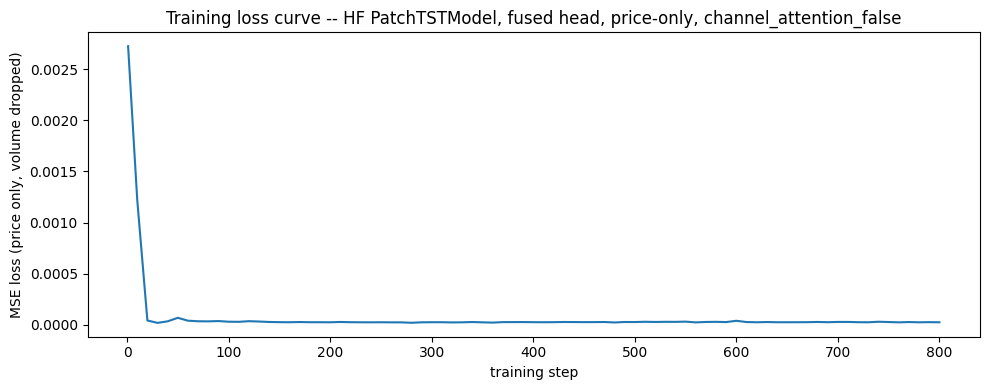

  OHLC RMSE        : 3.7251
  dir acc per bar  : 0.4635 / 0.4585 / 0.5515
  wrote steven/comparison_metrics/hf_patchtst_fused_head_no_volume-channel_attention_false.json

training channel_attention_true
epoch  1/20  train_loss=0.000620  val_loss=0.000224
epoch  2/20  train_loss=0.000044  val_loss=0.000040
epoch  3/20  train_loss=0.000030  val_loss=0.000026
epoch  4/20  train_loss=0.000025  val_loss=0.000024
epoch  5/20  train_loss=0.000023  val_loss=0.000022
epoch  6/20  train_loss=0.000023  val_loss=0.000021
epoch  7/20  train_loss=0.000023  val_loss=0.000020
epoch  8/20  train_loss=0.000023  val_loss=0.000020
epoch  9/20  train_loss=0.000023  val_loss=0.000020
epoch 10/20  train_loss=0.000024  val_loss=0.000021
epoch 11/20  train_loss=0.000025  val_loss=0.000024
epoch 12/20  train_loss=0.000025  val_loss=0.000025
epoch 13/20  train_loss=0.000023  val_loss=0.000024
epoch 14/20  train_loss=0.000022  val_loss=0.000025
epoch 15/20  train_loss=0.000022  val_loss=0.000023
epoch 16/20  trai

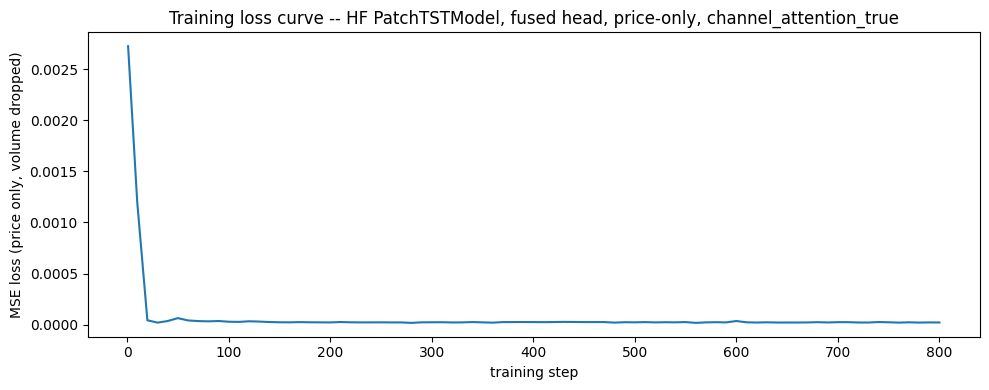

  OHLC RMSE        : 3.4506
  dir acc per bar  : 0.4635 / 0.5407 / 0.4476
  wrote steven/comparison_metrics/hf_patchtst_fused_head_no_volume-channel_attention_true.json


In [23]:
def run_epoch(model, loader, optimizer, device, train: bool, loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, n = 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        y = batch['y'].to(device).reshape(-1, HORIZON, N_FORECAST_CHANNELS)

        with torch.set_grad_enabled(train):
            price = model(past_values)
            loss = price_only_mse_loss(price, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = y.shape[0]
        total += loss.item() * bs
        n += bs
    return {'loss': total / n}


def rmse(pred: np.ndarray, true: np.ndarray) -> float:
    return float(np.sqrt(np.mean((pred - true) ** 2)))


def evaluate(model) -> dict:
    model.eval()
    all_true_y, all_pred_y, all_close0 = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            pv = batch['past_values'].to(DEVICE)
            price = model(pv)
            all_true_y.append(batch['y'].numpy())
            all_pred_y.append(price.reshape(price.shape[0], -1).cpu().numpy())
            all_close0.append(batch['close_0'])

    true_y = np.concatenate(all_true_y)
    pred_y = np.concatenate(all_pred_y)
    close_0 = np.concatenate(all_close0)
    n = len(true_y)

    true_price = true_y.reshape(n, 3, 4)
    pred_price = pred_y.reshape(n, 3, 4)
    true_ohlc = reconstruct_prices(true_price, close_0)
    pred_ohlc = reconstruct_prices(pred_price, close_0)
    ohlc_rmse = rmse(pred_ohlc, true_ohlc)

    true_close_ret = true_price[:, :, 0] + true_price[:, :, 1]
    pred_close_ret = pred_price[:, :, 0] + pred_price[:, :, 1]
    dir_acc = (np.sign(pred_close_ret) == np.sign(true_close_ret)).mean(axis=0)

    return {
        'n_windows': n,
        'ohlc_rmse': ohlc_rmse,
        'directional_accuracy': dir_acc.tolist(),
    }


os.makedirs('steven/comparison_metrics', exist_ok=True)
results = {}

for channel_attention in CHANNEL_ATTENTION_SETTINGS:
    setting_key = f'channel_attention_{str(channel_attention).lower()}'
    print(f'\n{"="*70}\ntraining {setting_key}\n{"="*70}')

    # Reset the seed per setting so both runs get identical weight init/dropout draws --
    # data order is already independent of global RNG state (np.random.default_rng(SEED+epoch)
    # below), but model init/dropout use torch's global RNG, which would otherwise have
    # already been advanced by whichever setting trained first.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = build_model(channel_attention).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    loss_history = []
    step_holder = [0]
    best_val_loss = float('inf')

    for epoch in range(MAX_EPOCHS):
        train_rng = np.random.default_rng(SEED + epoch)
        n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
        train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
        train_ds = FixedContextDataset(feat, opens, closes, train_starts)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

        train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, train=True,
                                   loss_history=loss_history, step_holder=step_holder)
        val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

        print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
              f'train_loss={train_metrics["loss"]:.6f}  val_loss={val_metrics["loss"]:.6f}')

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']

    print(f'done ({setting_key}). best val_loss={best_val_loss:.6f}')

    fig, ax = plt.subplots(figsize=(10, 4))
    steps, losses = zip(*loss_history)
    ax.plot(steps, losses)
    ax.set_xlabel('training step')
    ax.set_ylabel('MSE loss (price only, volume dropped)')
    ax.set_title(f'Training loss curve -- HF PatchTSTModel, fused head, price-only, {setting_key}')
    plt.tight_layout()
    plt.show()

    eval_metrics = evaluate(model)
    print(f'  OHLC RMSE        : {eval_metrics["ohlc_rmse"]:.4f}')
    dir_acc = eval_metrics['directional_accuracy']
    print(f'  dir acc per bar  : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')

    output = {
        'experiment': {**EXPERIMENT, 'channel_attention': channel_attention, 'seed': SEED},
        'best_val_loss': best_val_loss,
        **eval_metrics,
    }
    results[setting_key] = output

    out_path = f'steven/comparison_metrics/{EXPERIMENT["name"]}-{setting_key}.json'
    with open(out_path, 'w') as f:
        json.dump(output, f, indent=2)
    print(f'  wrote {out_path}')


## Results summary

In [24]:
print(f'{"setting":<26} {"OHLC RMSE":>10} {"dir acc (bar1/2/3)":>22}')
for setting_key, r in results.items():
    da = r['directional_accuracy']
    print(f'{setting_key:<26} {r["ohlc_rmse"]:>10.4f} '
          f'{da[0]:>6.4f}/{da[1]:.4f}/{da[2]:.4f}')


setting                     OHLC RMSE     dir acc (bar1/2/3)
channel_attention_false        3.7251 0.4635/0.4585/0.5515
channel_attention_true         3.4506 0.4635/0.5407/0.4476


## Caveats and recommended next steps

- **Read directional accuracy before OHLC RMSE this round.** This exact combination
  (return target + volume dropped) previously produced a much better OHLC RMSE but a
  backtest with **zero trades at every threshold** on this branch -- see the intro
  markdown's "known risk" note. A big RMSE win paired with directional accuracy at/near
  chance (~0.50) would be that same collapse recurring, not a genuine improvement.
- **`reparam`-space error is no longer tracked** (dropped along with MAE in the step-1
  simplification) -- `ohlc_rmse` (real $) and `directional_accuracy` are the only two
  numbers this notebook reports now.
- **One seed per setting.** `CHANNEL_ATTENTION_SETTINGS` controls which settings get
  trained in this pass -- both by default.
- **Fixed context (70 bars) vs. steven's variable-length curriculum.** Compare against
  steven's "long" bucket, not "overall".
- **No backtest yet.** Deferred until a target/volume variant is picked from the
  forecasting-metrics ladder (fused-head parity -> drop volume -> raw-price+volume ->
  raw-price-no-volume -> head comparison).
- **`evaluate.py` does NOT support this checkpoint shape.** It expects a 15-dim
  (price+volume) output and `src.losses.unpack_y`/`weighted_mse_loss`, neither of which
  apply here -- this notebook computes its own metrics inline instead (no checkpoint
  saved this round either, since none of the earlier steps' checkpoints are wired into a
  shared eval path -- see backlog for a possible dedicated price-only eval path).
- **Reusing this notebook for the next step** (raw-price target +/- volume): update
  `EXPERIMENT["name"]`/`["description"]`/`["target"]`/`["include_volume"]` in the imports
  cell, and the model/data/loss cells as needed -- don't fork a new notebook file.


## Commit + push results

Same pattern as `steven/colab_train.ipynb`'s own commit/push cells -- reused here so every
experiment notebook that runs on a fresh Colab VM handles git auth the same way.


In [25]:
# Fresh Colab VM has no git identity configured -- needed for `commit` to work at all.
# Only sets it for this local clone (no --global), harmless to commit/share.
!git -C {REPO_DIR} config user.email "woodychang891121@gmail.com"
!git -C {REPO_DIR} config user.name "WoodyChang21"

commit_msg = f"chore(model): log {EXPERIMENT['name']} comparison_metrics from this Colab run"

!git add steven/comparison_metrics
!git status
!git commit -m {commit_msg!r}


On branch patchtst_ohlcv_mse
Your branch is up to date with 'origin/patchtst_ohlcv_mse'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   steven/comparison_metrics/hf_patchtst_fused_head_no_volume-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_fused_head_no_volume-channel_attention_true.json

[patchtst_ohlcv_mse 56bd6b5] chore(model): log hf_patchtst_fused_head_no_volume comparison_metrics from this Colab run
 2 files changed, 42 insertions(+)
 create mode 100644 steven/comparison_metrics/hf_patchtst_fused_head_no_volume-channel_attention_false.json
 create mode 100644 steven/comparison_metrics/hf_patchtst_fused_head_no_volume-channel_attention_true.json


In [26]:
import getpass

# Fresh Colab VM has no stored GitHub credentials, so a plain `git push` over HTTPS
# can't authenticate. Prompting interactively (getpass masks it, and it's never written
# into this notebook's saved source/outputs) instead of hardcoding a token in a cell --
# a hardcoded token would get committed into git history the moment this notebook is
# pushed, which is a real credential leak. Needs a GitHub Personal Access Token with
# `repo` scope: https://github.com/settings/tokens
token = getpass.getpass("GitHub Personal Access Token: ")
push_url = f"https://{token}@github.com/WoodyChang21/ECE1508_GenAI.git"
!git -C {REPO_DIR} push {push_url} {BRANCH}
del token, push_url  # don't leave it sitting in a notebook-visible variable longer than needed


Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 12 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 1.14 KiB | 1.14 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 2 local objects.
To https://github.com/WoodyChang21/ECE1508_GenAI.git
   0d2b7ec..56bd6b5  patchtst_ohlcv_mse -> patchtst_ohlcv_mse
